In [324]:
import math
import os
import sys
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns  # noqa: F811
from scipy import stats  # noqa: F811
from statsmodels.stats.outliers_influence import variance_inflation_factor

sys.path.insert(0, str(Path.cwd().parent))

from utils.bivaraite_boxplot import plot_segmented_boxplot
from utils.cat_num_dep import hub_pruebas_num_cat
from utils.corr_vector import plot_target_correlation
from utils.fancy_barplot import fancy_bars, plot_cat_relation
from utils.mutual_inf_plot import analizar_relevancia_caracteristicas
from utils.plotting import EDAPlotter

In [325]:
df = pd.read_csv("../data/datos_inmobiliarios_clean.csv")

In [326]:
plotter = EDAPlotter(df)

# Split amenities

In [327]:
df["amenities"].str.split("|")

0        [Alarma, Baño Auxiliar, Calentador, Canchas De...
1        [Baño Auxiliar, Colegios / Universidades, Estu...
2        [Baño Auxiliar, Calentador, Cancha de Tennis, ...
3        [Ascensor, Barra estilo americano, Baño Auxili...
4        [Balcón, Barra estilo americano, Baño Auxiliar...
                               ...                        
20248    [Alcantarillado, Baño Auxiliar, Cerca centro c...
20249    [Cerca a sector comercial, Cerca centro comerc...
20250    [Ascensor, Baño Auxiliar, Calentador, Cerca a ...
20251                                            [Ninguna]
20252    [Auditorio, Baño Auxiliar, Baño de Servicio, C...
Name: amenities, Length: 20253, dtype: object

In [328]:
amenidades_frecuencia = df["amenities"].str.split("|").explode().value_counts()

amenidades_frecuencia.head(5)

amenities
Trans. Público cercano    13707
Zona Residencial          12518
Cocina Integral           11813
Zona de lavandería        11276
Instalación de gas        10886
Name: count, dtype: int64

Ya que hay muchas amenidades se tomaran como variable binaria solo las mas comunes, es decir: 
* Trans. Público cercano
* Zona Residencial

ademas se creara una columna `n_amenities`

In [329]:
df["Trans Publico cerc"] = (
    df["amenities"]
    .str.split("|")
    .apply(lambda x: "Trans. Público cercano" in x)
)

In [330]:
df["Zona Residencial"] = (
    df["amenities"].str.split("|").apply(lambda x: "Zona Residencial" in x)
)

In [331]:
df["n_amenities"] = (
    df["amenities"]
    .str.split("|")
    .apply(lambda x: len(x) if "Ninguna" not in x else 0)
)
bins = [-1, 0, 5, 15, 30, np.inf]
labels = [
    "Sin amenidades (0)",
    "Pocas (1-5)",
    "Considerables (6-15)",
    "Muchas (16-30)",
    "Demasiadas (>30)",
]

# 2. Crear la nueva variable agrupada
df["n_amenities_range"] = pd.cut(df["n_amenities"], bins=bins, labels=labels)

In [332]:
df["Trans Publico cerc"].value_counts()

Trans Publico cerc
True     13707
False     6546
Name: count, dtype: int64

In [333]:
df["Zona Residencial"].value_counts()

Zona Residencial
True     12518
False     7735
Name: count, dtype: int64

In [334]:
df["n_amenities"].value_counts()

n_amenities
0     1515
12     790
14     782
11     711
15     679
      ... 
57       7
58       7
52       6
56       4
54       4
Name: count, Length: 65, dtype: int64

In [335]:
df["n_amenities_range"].value_counts()  # solo descriptiva

n_amenities_range
Muchas (16-30)          7320
Considerables (6-15)    6411
Demasiadas (>30)        2648
Pocas (1-5)             2359
Sin amenidades (0)      1515
Name: count, dtype: int64

<Axes: title={'left': 'Comparación de viviendas en zona residencial'}, xlabel='Zona Residencial', ylabel='Conteo'>

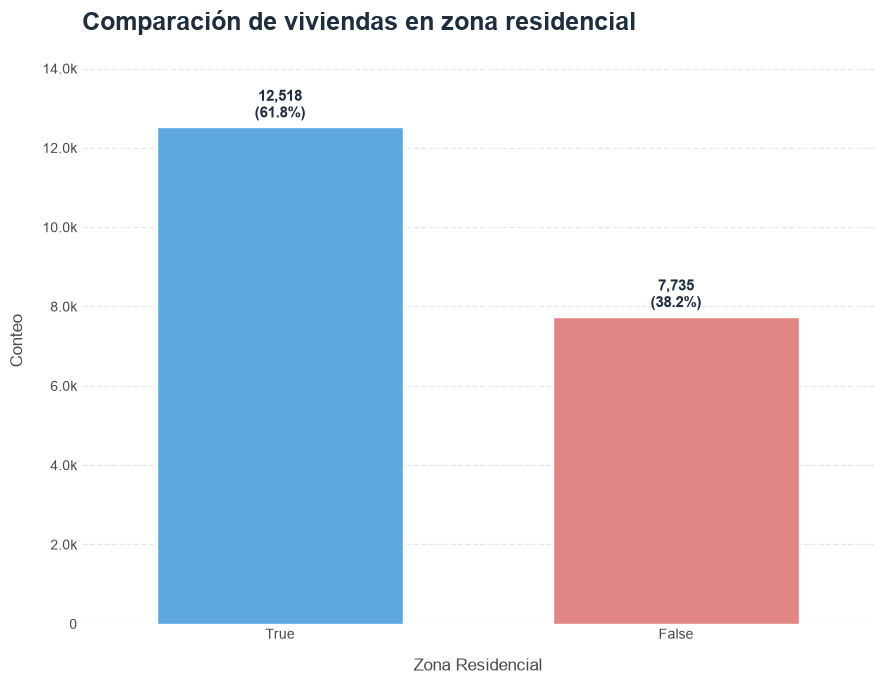

In [336]:
fancy_bars(
    df,
    "Zona Residencial",
    labels="both",
    title="Comparación de viviendas en zona residencial",
)

La mayoria de propiedades en  el set estan reportadas como zona residencial

<Axes: title={'left': 'Comparación de viviendas con transporte cercano'}, xlabel='Trans Publico Cerc', ylabel='Conteo'>

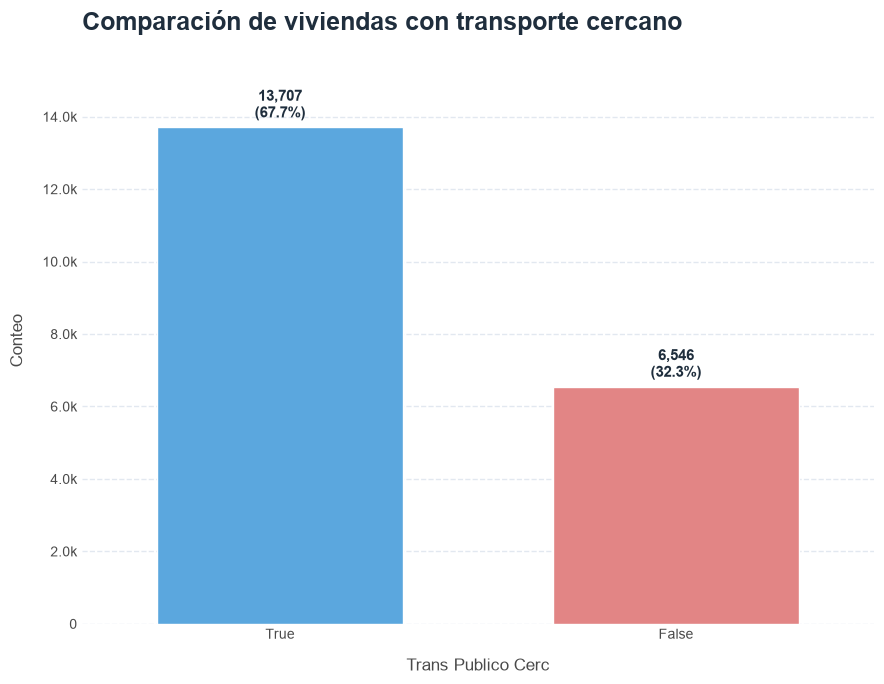

In [337]:
fancy_bars(
    df,
    "Trans Publico cerc",
    labels="both",
    title="Comparación de viviendas con transporte cercano",
)

La mayoria de biviendas dicen tener transporte cerca

<Axes: title={'left': 'Numero de amenidades'}, xlabel='N Amenities Range', ylabel='Conteo'>

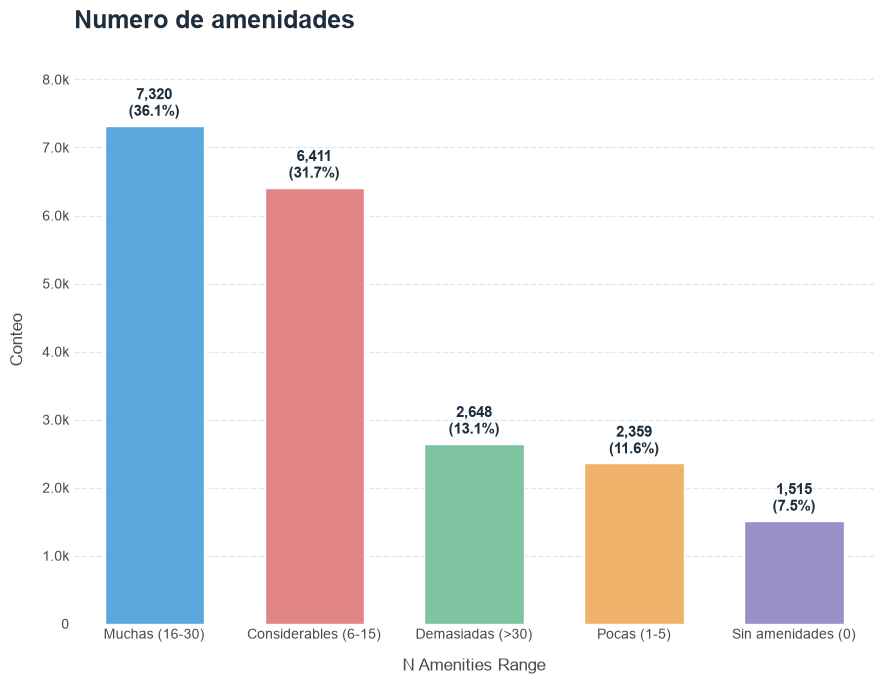

In [338]:
fancy_bars(
    df, "n_amenities_range", labels="both", title="Numero de amenidades"
)

La mayor parte de biviendas reportan entre 16 y 30 amenidades, y son muy pocas las que no reportan ninguna clase de amenidad

# Relacion de las nuevas variables con el precio

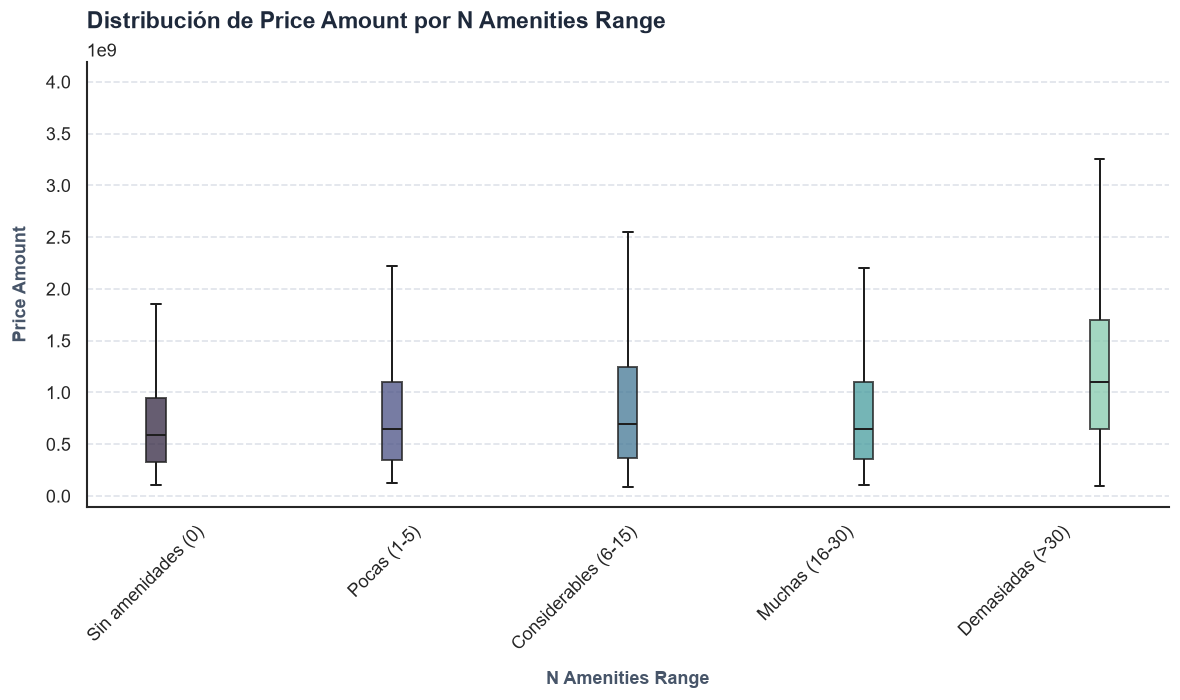

In [339]:
plot_segmented_boxplot(
    df, "price_amount", "n_amenities_range", show_points=False
)

Aquellas viviendas con demasiadas amenidades (mas de 30) son mas caras, aunque tambien tienen un rango muy amplio, viviendas muy caras y muy baratas

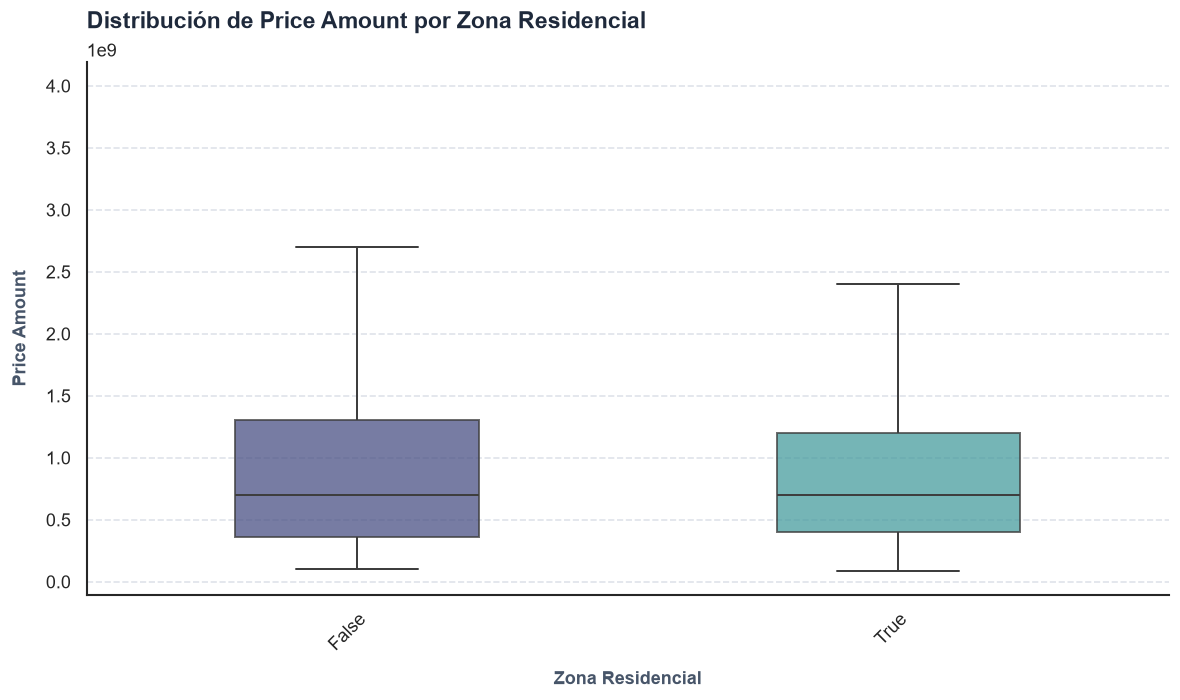

In [340]:
plot_segmented_boxplot(
    df, "price_amount", "Zona Residencial", show_points=False
)

No se aprecia una diferencia muy grande entre grupos

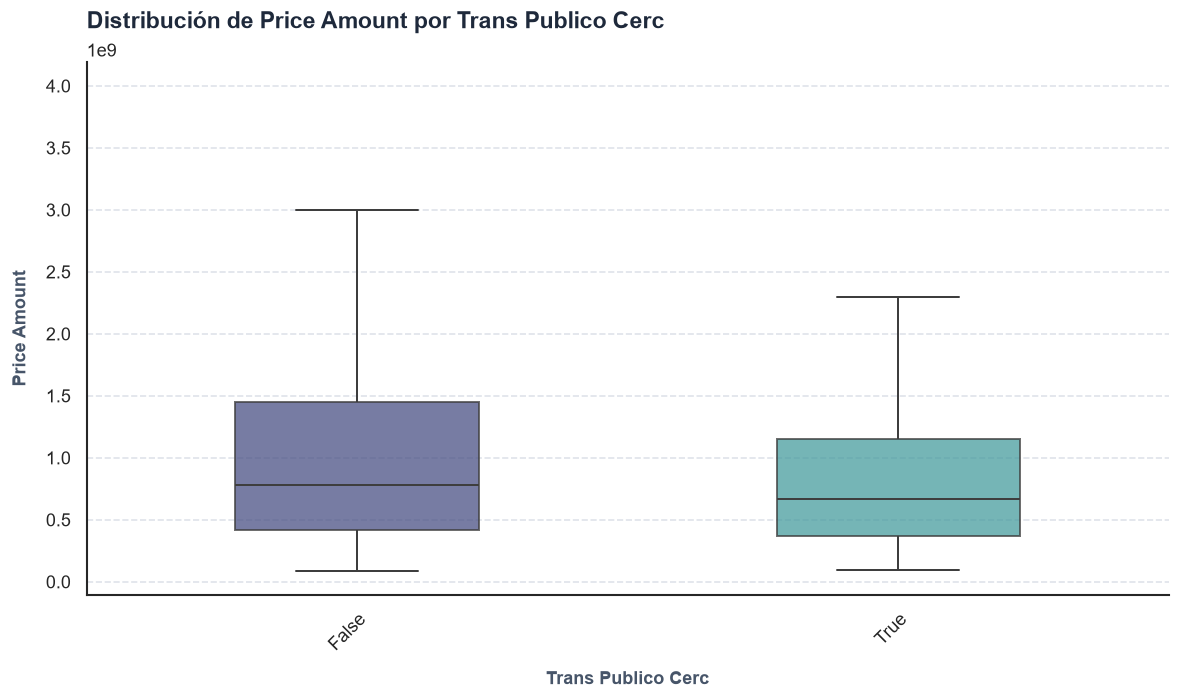

In [341]:
plot_segmented_boxplot(
    df, "price_amount", "Trans Publico cerc", show_points=False
)

Hay una sutil diferencia entre los 2 grupos, las viviendas que no tienen transporte publico cerca tienen una mediana mas alta, posiblemente por propiedades de lujo

<Axes: title={'left': 'Distribución de Trans Publico Cerc por Property Type'}, xlabel='Property Type', ylabel='Conteo'>

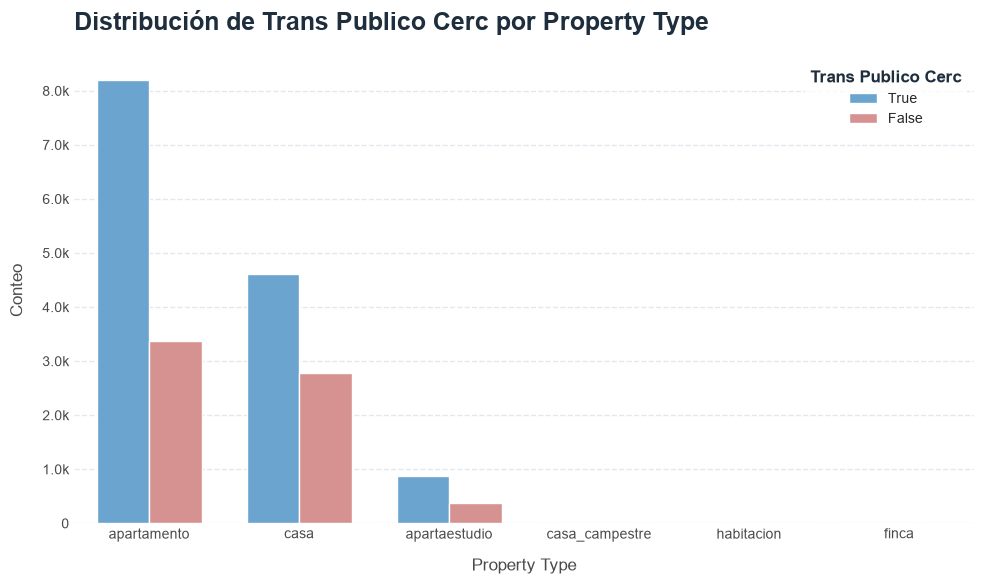

In [342]:
plot_cat_relation(df, "property_type", "Trans Publico cerc")

In [343]:
def plot_counts_by_price_threshold(
    df: pd.DataFrame,
    threshold: float,
    cat_col: str = "trans_publico_cerc",
    num_col: str = "price_amount",
    title: str | None = None,
    palette: list[str] = ["#6B7098", "#6BB3B3"],
    figsize: tuple[float, float] = (9, 6),
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """Segmenta los conteos de una variable categórica según si 'num_col'
    es mayor o menor/igual a un threshold dado.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    df_plot = df.copy()

    # Formatear el threshold para etiquetas legibles (K, M, B)
    if threshold >= 1e9:
        thresh_str = f"{threshold / 1e9:.1f}B"
    elif threshold >= 1e6:
        thresh_str = f"{threshold / 1e6:.1f}M"
    elif threshold >= 1e3:
        thresh_str = f"{threshold / 1e3:.1f}K"
    else:
        thresh_str = f"{threshold:,.0f}"

    segment_col = f"{num_col}_segment"
    df_plot[segment_col] = np.where(
        df_plot[num_col] <= threshold, f"≤ {thresh_str}", f"> {thresh_str}"
    )

    # Configuración del estilo base
    ax.set_facecolor("white")

    # Dibujar el gráfico de conteo agrupado
    sns.countplot(
        data=df_plot,
        x=cat_col,
        hue=segment_col,
        palette=palette,
        ax=ax,
        edgecolor="#2C3E50",
        linewidth=0.8,
    )

    # 1. Grilla horizontal punteada
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle="--", color="#E2E8F0", linewidth=1.0)
    ax.xaxis.grid(False)

    # 2. Despine (eliminar bordes superior y derecho)
    sns.despine(ax=ax, top=True, right=True)

    # 3. Personalización de Título y Ejes
    text_color = "#1F2E3D"
    cat_label = cat_col.replace("_", " ").title()
    num_label = num_col.replace("_", " ").title()

    default_title = (
        f"Conteo de {cat_label} por Umbral de {num_label} ({thresh_str})"
    )

    ax.set_title(
        title or default_title,
        loc="left",
        fontweight="bold",
        fontsize=13,
        color=text_color,
        pad=20,
    )

    ax.set_xlabel(
        cat_label,
        fontweight="bold",
        color=text_color,
        fontsize=11,
        labelpad=12,
    )

    ax.set_ylabel(
        "Conteo",
        fontweight="bold",
        color=text_color,
        fontsize=11,
        labelpad=12,
    )

    ax.tick_params(axis="both", labelsize=10, colors=text_color)

    # 4. Leyenda
    legend = ax.legend(
        title=num_label,
        frameon=True,
        facecolor="white",
        edgecolor="none",
    )
    if legend:
        legend.get_title().set_fontweight("bold")
        legend.get_title().set_color(text_color)

    plt.tight_layout()
    return ax

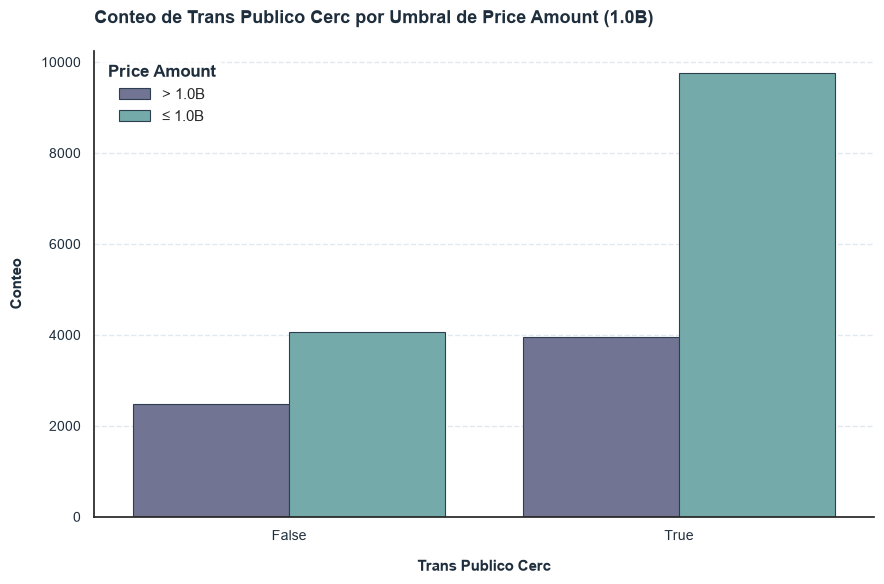

In [344]:
plot_counts_by_price_threshold(
    df=df,
    threshold=1_000_000_000,
    cat_col="Trans Publico cerc",
    num_col="price_amount",
)
plt.show()

las viviendas mas caras tienden a no tener transporte publico cerca, vea como la bracha entre las barras moradas (vivendas caras), es mas pequeña que en las grises, por lo tanto es mas comun que cuando las viviendas de lujo no haya transporte cercano, mientras que viviendas normales en su gran mayoria si lo tienen.

 las viviendas de lujo tienen una mayor propensión relativa a carecer de transporte público ($\approx 38.5\%$) en comparación con las viviendas estándar ($\approx 29.0\%$).

# Pruebas de hipotesis con las nuevas variables

In [345]:
cat_vars = ["Zona Residencial", "Trans Publico cerc", "n_amenities_range"]

In [346]:
hub_pruebas_num_cat(df, "price_amount", cat_vars)

,var_numerica,var_categorica,n_grupos,prueba,estadistico,p_valor,normalidad,homocedasticidad,decision,conclusion,post_hoc
0,price_amount,Trans Publico cerc,2,U de Mann-Whitney,4.962846e+07,0.000000,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,
1,price_amount,n_amenities_range,5,Kruskal-Wallis (H),9.092965e+02,0.000000,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,Sin amenidades (0) vs Pocas (1-5) (p=0.0007); ...
2,price_amount,Zona Residencial,2,U de Mann-Whitney,4.825396e+07,0.693352,no,no,No se rechaza H0,Independencia: no hay evidencia de diferencia,


Como se sospechaba  graficamente el precio y el transporte publico cecano tienen relacion, las viviendas mas caras tienden a no tener transporte publico cerca (de ahi la dependencia), no hay algun efecto significativo con el hecho de ser de una zona residencial y el numero de amenidades que se reporta si tiene relacion con el precio

In [347]:
df.drop(columns="n_amenities_range", inplace=True)

# Alistando caracteristicas

In [348]:
df.columns

Index(['property_type', 'price_amount', 'admin_fee', 'price_per_m2',
       'area_built_m2', 'area_private_m2', 'bedrooms', 'bathrooms',
       'parking_spaces', 'stratum', 'floor', 'age_bracket_code',
       'age_bracket_label', 'construction_state', 'city', 'locality',
       'neighborhood', 'latitude', 'longitude', 'amenities', 'agency_name',
       'publisher_type', 'pub_month', 'mod_month', 'log_price_amount',
       'Trans Publico cerc', 'Zona Residencial', 'n_amenities'],
      dtype='str')

In [349]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20253 entries, 0 to 20252
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_type       20253 non-null  str    
 1   price_amount        20253 non-null  float64
 2   admin_fee           20253 non-null  float64
 3   price_per_m2        20253 non-null  float64
 4   area_built_m2       20253 non-null  float64
 5   area_private_m2     20253 non-null  float64
 6   bedrooms            20253 non-null  float64
 7   bathrooms           20253 non-null  float64
 8   parking_spaces      20253 non-null  int64  
 9   stratum             20253 non-null  float64
 10  floor               20253 non-null  int64  
 11  age_bracket_code    20253 non-null  float64
 12  age_bracket_label   20253 non-null  str    
 13  construction_state  20253 non-null  str    
 14  city                20253 non-null  str    
 15  locality            20253 non-null  str    
 16  neighborhood   

## 1. Columnas categoricas

Se llevaran a cabo las codificaciones correspondientes.

In [350]:
df.drop(columns=["age_bracket_label", "amenities"], inplace=True)

In [351]:
cat_cols = [
    "construction_state",
    "city",
    "locality",
    "neighborhood",
    "agency_name",
    "publisher_type",
    "property_type",
]

In [352]:
for col in cat_cols:
    n_cats = len(df[col].unique())
    opt_txt = "one hot" if n_cats <= 10 else "target_enc"
    print(
        f"{col} tiene {n_cats} categorias diferentes, se recomienda usar {opt_txt}\n"  # noqa: E501
    )

construction_state tiene 10 categorias diferentes, se recomienda usar one hot

city tiene 4 categorias diferentes, se recomienda usar one hot

locality tiene 21 categorias diferentes, se recomienda usar target_enc

neighborhood tiene 1108 categorias diferentes, se recomienda usar target_enc

agency_name tiene 1157 categorias diferentes, se recomienda usar target_enc

publisher_type tiene 3 categorias diferentes, se recomienda usar one hot

property_type tiene 6 categorias diferentes, se recomienda usar one hot



### `construction_state` 

In [353]:
most_common_states = df["construction_state"].value_counts().nlargest(4).index

In [354]:
df["construction_state"].value_counts()

construction_state
Usado                     17748
Excelente estado           1759
Buen estado                 466
A estrenar                  211
En construcción              19
En Pozo                      16
Requiere mantenimiento       15
Reciclada                    10
Sobre planos                  7
Nuevos                        2
Name: count, dtype: int64

In [355]:
df["construction_state_grouped"] = df["construction_state"].where(
    df["construction_state"].isin(most_common_states), "Otros"
)

In [356]:
df["construction_state_grouped"].value_counts()

construction_state_grouped
Usado               17748
Excelente estado     1759
Buen estado           466
A estrenar            211
Otros                  69
Name: count, dtype: int64

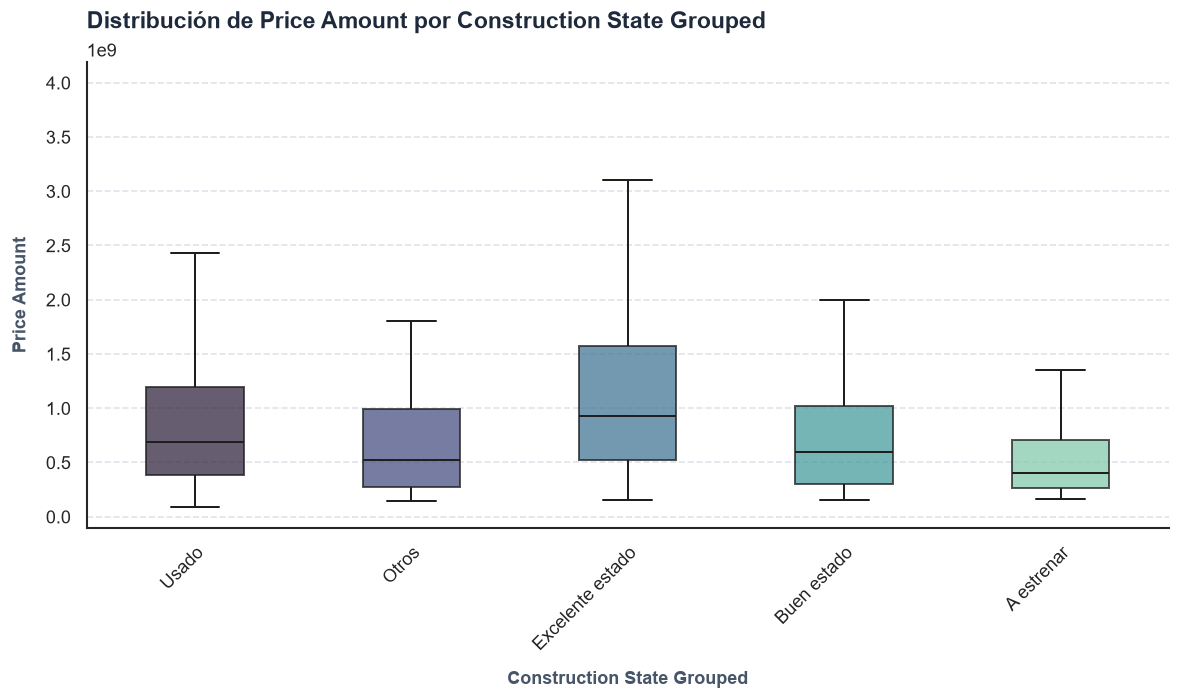

In [357]:
plot_segmented_boxplot(
    df, "price_amount", "construction_state_grouped", show_points=False
)

In [358]:
hub_pruebas_num_cat(df, "price_amount", ["construction_state_grouped"])

,var_numerica,var_categorica,n_grupos,prueba,estadistico,p_valor,normalidad,homocedasticidad,decision,conclusion,post_hoc
0,price_amount,construction_state_grouped,5,Kruskal-Wallis (H),282.7877,0.0,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,A estrenar vs Buen estado (p=0.0000); A estren...


`construction_state_grouped` mantiene la dependencia original, procederemos a la eliminacion de `construction_state` y la codificacion de la nueva variable.

In [359]:
df.drop(columns=["construction_state"], inplace=True)

In [360]:
df["construction_state_grouped"].value_counts()

construction_state_grouped
Usado               17748
Excelente estado     1759
Buen estado           466
A estrenar            211
Otros                  69
Name: count, dtype: int64

In [361]:
df = pd.get_dummies(df, columns=["construction_state_grouped"], dtype=int)
df.drop(
    columns=["construction_state_grouped_Usado"], inplace=True
)  # la mas comun

In [362]:
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,pub_month,mod_month,log_price_amount,Trans Publico cerc,Zona Residencial,n_amenities,construction_state_grouped_A estrenar,construction_state_grouped_Buen estado,construction_state_grouped_Excelente estado,construction_state_grouped_Otros
0,casa,8.800000e+08,736000.00,5.500000e+06,160.0000,151.0,3.0,3.0,2,4.0,...,2023-01,2026-06,20.595432,True,True,25,0,0,0,0
1,casa,6.500000e+08,196727.91,4.237288e+06,153.4000,153.4,4.0,2.0,1,3.0,...,2023-01,2026-07,20.292483,True,False,8,0,0,0,0
2,casa,6.250000e+08,643500.00,5.208333e+06,120.0000,120.0,4.0,3.0,2,5.0,...,2023-02,2026-06,20.253262,True,True,27,0,0,0,0
3,apartamento,4.700000e+08,560000.00,8.392857e+06,56.0000,58.0,1.0,2.0,1,4.0,...,2023-03,2026-07,19.968243,True,True,35,0,0,0,0
4,casa,3.300000e+09,1317625.80,8.230622e+06,369.7528,350.0,4.0,3.0,2,6.0,...,2023-03,2026-06,21.917188,False,False,12,0,0,0,0


### `city `

In [363]:
df["city"].value_counts()

city
Bogotá       19901
Chía           193
Soacha         149
Zipaquirá       10
Name: count, dtype: int64

<Axes: title={'left': 'Distribución de City'}, xlabel='City', ylabel='Conteo'>

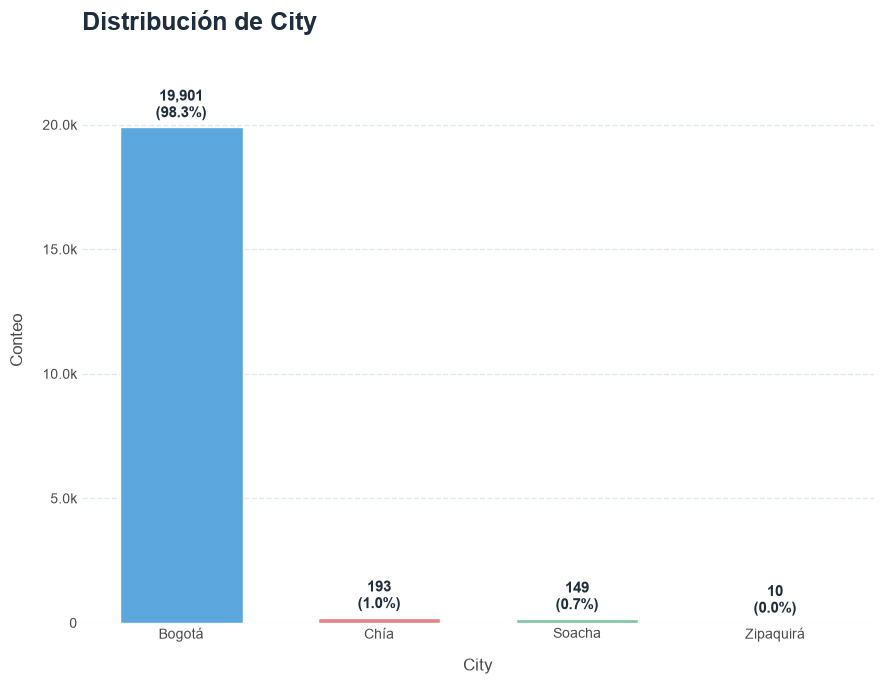

In [364]:
fancy_bars(df, "city", labels="both")

Usaremos one-hot encoder, esta variable es particularmente importante pues chia tiene los inmuebles mas costosos (vea el boxplot comparativo en bivariate_eda)

In [365]:
df = pd.get_dummies(df, columns=["city"], dtype=int, drop_first=True)

In [366]:
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,Trans Publico cerc,Zona Residencial,n_amenities,construction_state_grouped_A estrenar,construction_state_grouped_Buen estado,construction_state_grouped_Excelente estado,construction_state_grouped_Otros,city_Chía,city_Soacha,city_Zipaquirá
0,casa,8.800000e+08,736000.00,5.500000e+06,160.0000,151.0,3.0,3.0,2,4.0,...,True,True,25,0,0,0,0,0,0,0
1,casa,6.500000e+08,196727.91,4.237288e+06,153.4000,153.4,4.0,2.0,1,3.0,...,True,False,8,0,0,0,0,0,0,0
2,casa,6.250000e+08,643500.00,5.208333e+06,120.0000,120.0,4.0,3.0,2,5.0,...,True,True,27,0,0,0,0,0,0,0
3,apartamento,4.700000e+08,560000.00,8.392857e+06,56.0000,58.0,1.0,2.0,1,4.0,...,True,True,35,0,0,0,0,0,0,0
4,casa,3.300000e+09,1317625.80,8.230622e+06,369.7528,350.0,4.0,3.0,2,6.0,...,False,False,12,0,0,0,0,0,0,0


### `locality`

target enc

In [367]:
reemplazos = {
    "Engativa": "Engativá",
    "Fontibon": "Fontibón",
    "LA Candelaria": "La Candelaria",
}

# Aplicar el reemplazo en el DataFrame
df["locality"] = df["locality"].replace(reemplazos)

In [368]:
df["locality"].value_counts()

locality
Usaquen           6344
Suba              5473
Teusaquillo       1426
Kennedy           1251
Barrios Unidos    1213
Engativá           773
Fontibón           651
Puente Aranda      524
Bosa               485
Chapinero          428
Los Martires       355
Santafe            336
Ciudad Bolivar     313
Antonio Nariño     255
San Cristobal      222
Tunjuelito         114
Rafael Uribe        48
La Candelaria       27
Usme                15
Name: count, dtype: int64

In [369]:
len(df["locality"].unique())

19

In [370]:
frec_por_localidad = df["locality"].value_counts(normalize=True)

df["locality_frec"] = df["locality"].map(frec_por_localidad)

df.drop(columns=["locality"], inplace=True)

In [371]:
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,Zona Residencial,n_amenities,construction_state_grouped_A estrenar,construction_state_grouped_Buen estado,construction_state_grouped_Excelente estado,construction_state_grouped_Otros,city_Chía,city_Soacha,city_Zipaquirá,locality_frec
0,casa,8.800000e+08,736000.00,5.500000e+06,160.0000,151.0,3.0,3.0,2,4.0,...,True,25,0,0,0,0,0,0,0,0.270232
1,casa,6.500000e+08,196727.91,4.237288e+06,153.4000,153.4,4.0,2.0,1,3.0,...,False,8,0,0,0,0,0,0,0,0.059892
2,casa,6.250000e+08,643500.00,5.208333e+06,120.0000,120.0,4.0,3.0,2,5.0,...,True,27,0,0,0,0,0,0,0,0.313238
3,apartamento,4.700000e+08,560000.00,8.392857e+06,56.0000,58.0,1.0,2.0,1,4.0,...,True,35,0,0,0,0,0,0,0,0.313238
4,casa,3.300000e+09,1317625.80,8.230622e+06,369.7528,350.0,4.0,3.0,2,6.0,...,False,12,0,0,0,0,0,0,0,0.270232


### `neighborhood`

In [372]:
df["neighborhood"].value_counts()

neighborhood
San Jose DE Bavaria         643
Barrios Unidos              608
Santa Barbara Central       563
Santa Paula                 521
Santa Barbara Occidental    407
                           ... 
Tintalito                     1
Trinidad Galan                1
Banco Central                 1
Salitre Nor - Occidental      1
Centro Fontibon               1
Name: count, Length: 1108, dtype: int64

In [373]:
len(df["neighborhood"].unique())

1108

In [374]:
top_20_neighborhoods = df["neighborhood"].value_counts().nlargest(20).index
top_20_neighborhoods

Index(['San Jose DE Bavaria', 'Barrios Unidos', 'Santa Barbara Central',
       'Santa Paula', 'Santa Barbara Occidental', 'Navarra', 'Chapinero',
       'Engativá', 'LA Calleja', 'Niza Suba', 'Altos DE Bella Suiza',
       'Bosque DE Pinos', 'Chapinero Alto', 'Ilarco', 'Monaco',
       'Acacias Usaquen', 'Centro Comercial Parque LA Colina', 'Niza',
       'Veramonte Macana', 'LA Castellana'],
      dtype='str', name='neighborhood')

In [375]:
df["neighborhood_grouped"] = df["neighborhood"].where(
    df["neighborhood"].isin(top_20_neighborhoods), "Otros"
)

In [376]:
df.drop(columns=["neighborhood"], inplace=True)
len(df["neighborhood_grouped"].unique())

21

In [377]:
df["neighborhood_grouped"].value_counts()

neighborhood_grouped
Otros                                14087
San Jose DE Bavaria                    643
Barrios Unidos                         608
Santa Barbara Central                  563
Santa Paula                            521
Santa Barbara Occidental               407
Navarra                                399
Chapinero                              335
Engativá                               330
LA Calleja                             260
Niza Suba                              243
Altos DE Bella Suiza                   236
Bosque DE Pinos                        205
Chapinero Alto                         193
Ilarco                                 193
Monaco                                 188
Acacias Usaquen                        183
Centro Comercial Parque LA Colina      182
Niza                                   169
Veramonte Macana                       155
LA Castellana                          153
Name: count, dtype: int64

In [378]:
frec_por_barrio = df.groupby("neighborhood_grouped")["price_amount"].count()/df.shape[0]
df["neighborhood_grouped_frec"] = df["neighborhood_grouped"].map(
    frec_por_barrio
)
df.drop(columns=["neighborhood_grouped"], inplace=True)

In [379]:
df["neighborhood_grouped_frec"].unique()

array([0.69555128, 0.03174838, 0.02572458, 0.01629388, 0.03002024,
       0.0128376 , 0.02009579, 0.01970079, 0.02779835, 0.00765319,
       0.00834444, 0.01199822, 0.00928258, 0.00952945, 0.00898632,
       0.01165259, 0.01654076, 0.00755444, 0.01012196, 0.0090357 ])

In [380]:
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,n_amenities,construction_state_grouped_A estrenar,construction_state_grouped_Buen estado,construction_state_grouped_Excelente estado,construction_state_grouped_Otros,city_Chía,city_Soacha,city_Zipaquirá,locality_frec,neighborhood_grouped_frec
0,casa,8.800000e+08,736000.00,5.500000e+06,160.0000,151.0,3.0,3.0,2,4.0,...,25,0,0,0,0,0,0,0,0.270232,0.695551
1,casa,6.500000e+08,196727.91,4.237288e+06,153.4000,153.4,4.0,2.0,1,3.0,...,8,0,0,0,0,0,0,0,0.059892,0.695551
2,casa,6.250000e+08,643500.00,5.208333e+06,120.0000,120.0,4.0,3.0,2,5.0,...,27,0,0,0,0,0,0,0,0.313238,0.695551
3,apartamento,4.700000e+08,560000.00,8.392857e+06,56.0000,58.0,1.0,2.0,1,4.0,...,35,0,0,0,0,0,0,0,0.313238,0.695551
4,casa,3.300000e+09,1317625.80,8.230622e+06,369.7528,350.0,4.0,3.0,2,6.0,...,12,0,0,0,0,0,0,0,0.270232,0.031748


### `agency_name`

La eliminaremos para evitar que el modelo sea sesgado por la agencia que vende el inmuble y solo describa las caracteristicas de este

In [381]:
df.drop(columns=["agency_name"], inplace=True)

### `publisher_type`

In [382]:
df["publisher_type"].value_counts()

publisher_type
inmobiliaria     19291
Particular         911
desarrollador       51
Name: count, dtype: int64

In [383]:
df = pd.get_dummies(df, columns=["publisher_type"], dtype=int, drop_first=True)

In [384]:
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,construction_state_grouped_Buen estado,construction_state_grouped_Excelente estado,construction_state_grouped_Otros,city_Chía,city_Soacha,city_Zipaquirá,locality_frec,neighborhood_grouped_frec,publisher_type_desarrollador,publisher_type_inmobiliaria
0,casa,8.800000e+08,736000.00,5.500000e+06,160.0000,151.0,3.0,3.0,2,4.0,...,0,0,0,0,0,0,0.270232,0.695551,0,0
1,casa,6.500000e+08,196727.91,4.237288e+06,153.4000,153.4,4.0,2.0,1,3.0,...,0,0,0,0,0,0,0.059892,0.695551,0,0
2,casa,6.250000e+08,643500.00,5.208333e+06,120.0000,120.0,4.0,3.0,2,5.0,...,0,0,0,0,0,0,0.313238,0.695551,0,0
3,apartamento,4.700000e+08,560000.00,8.392857e+06,56.0000,58.0,1.0,2.0,1,4.0,...,0,0,0,0,0,0,0.313238,0.695551,0,0
4,casa,3.300000e+09,1317625.80,8.230622e+06,369.7528,350.0,4.0,3.0,2,6.0,...,0,0,0,0,0,0,0.270232,0.031748,0,1


### `property_type`

In [385]:
df["property_type"].value_counts()

property_type
apartamento       11579
casa               7396
apartaestudio      1248
casa_campestre       19
habitacion            7
finca                 4
Name: count, dtype: int64

no se combinan las de bajo conteo ya que la cardinalidad es baja y las casas campestres y fincas son las propiedades mas caras y habitaciones las mas barata, entoces se mezclaria e incluso confundiria esa informacion 

In [386]:
df = pd.get_dummies(df, columns=["property_type"], dtype=int)
df.drop(
    columns=["property_type_apartamento"], inplace=True
)  #  la mas comun (bajar  VIF)

In [387]:
df.head()

,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,floor,...,city_Zipaquirá,locality_frec,neighborhood_grouped_frec,publisher_type_desarrollador,publisher_type_inmobiliaria,property_type_apartaestudio,property_type_casa,property_type_casa_campestre,property_type_finca,property_type_habitacion
0,8.800000e+08,736000.00,5.500000e+06,160.0000,151.0,3.0,3.0,2,4.0,2,...,0,0.270232,0.695551,0,0,0,1,0,0,0
1,6.500000e+08,196727.91,4.237288e+06,153.4000,153.4,4.0,2.0,1,3.0,2,...,0,0.059892,0.695551,0,0,0,1,0,0,0
2,6.250000e+08,643500.00,5.208333e+06,120.0000,120.0,4.0,3.0,2,5.0,1,...,0,0.313238,0.695551,0,0,0,1,0,0,0
3,4.700000e+08,560000.00,8.392857e+06,56.0000,58.0,1.0,2.0,1,4.0,2,...,0,0.313238,0.695551,0,0,0,0,0,0,0
4,3.300000e+09,1317625.80,8.230622e+06,369.7528,350.0,4.0,3.0,2,6.0,2,...,0,0.270232,0.031748,0,1,0,1,0,0,0


## Consolidado final codificacion (columnas)

In [388]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20253 entries, 0 to 20252
Data columns (total 35 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   price_amount                                 20253 non-null  float64
 1   admin_fee                                    20253 non-null  float64
 2   price_per_m2                                 20253 non-null  float64
 3   area_built_m2                                20253 non-null  float64
 4   area_private_m2                              20253 non-null  float64
 5   bedrooms                                     20253 non-null  float64
 6   bathrooms                                    20253 non-null  float64
 7   parking_spaces                               20253 non-null  int64  
 8   stratum                                      20253 non-null  float64
 9   floor                                        20253 non-null  int64  
 10  age_brack

# un poco mas de preparacion

In [389]:
df.drop(columns=["log_price_amount", "price_per_m2"], inplace=True)

# excluirlas ya que son provenientes del price_amount

 Considerar tratar la varianza (transformaciones log, escalamientos etc, se haran en la fase de entrenamiento, iterando sobre el modelo)

In [390]:
for col in df.columns:
    try:
        print(f"varainza de {col}: {df[col].var()}")
    except Exception as e:
        print(f"error con {col}: {e}")

varainza de price_amount: 4.914938604067514e+17
varainza de admin_fee: 346079296438.85065
varainza de area_built_m2: 16398.100350726338
varainza de area_private_m2: 17384.359865835344
varainza de bedrooms: 4.057027305942654
varainza de bathrooms: 2.324921868523166
varainza de parking_spaces: 2.9849281856098475
varainza de stratum: 1.5019481828618717
varainza de floor: 13.237919734673
varainza de age_bracket_code: 2.0022058067948842
varainza de latitude: 0.002804098420975188
varainza de longitude: 0.0014988962966045463
error con pub_month: Cannot perform reduction 'var' with string dtype
error con mod_month: Cannot perform reduction 'var' with string dtype
varainza de Trans Publico cerc: 0.21875658365094547
varainza de Zona Residencial: 0.2360684691994092
varainza de n_amenities: 191.7033852206093
varainza de construction_state_grouped_A estrenar: 0.010310179624939849
varainza de construction_state_grouped_Buen estado: 0.022480635758562736
varainza de construction_state_grouped_Excelent

## Procesar mes de publicacion

<Axes: xlabel='pub_month'>

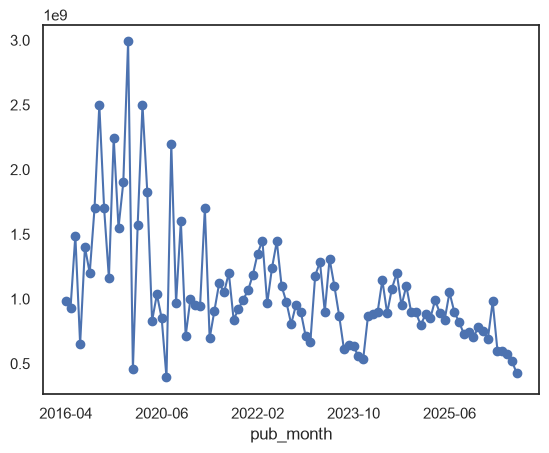

In [391]:
df.groupby("pub_month")["price_amount"].median().plot(marker="o")

A pesar que segun datos oficiales los precios de la vivienda en bogota han ido en subida la grafica muestra lo contrario, probelemente por sesgo de supervivencia, es decir que solo se recolectaron de esos años inmuebles caros que aun no se venden.

por lo tanto se hara una variable que indique cuanto tiempo lleva publicado el inmueble respecto a la fecha mas reciente del dataset.

In [392]:
df["pub_dt"] = pd.PeriodIndex(df["pub_month"], freq="M")

In [393]:
df["pub_dt"]

0        2023-01
1        2023-01
2        2023-02
3        2023-03
4        2023-03
          ...   
20248    2023-10
20249    2023-10
20250    2023-11
20251    2023-11
20252    2023-11
Name: pub_dt, Length: 20253, dtype: period[M]

In [394]:
ancla = df["pub_dt"].max()
df["meses_ofertado"] = ancla - df["pub_dt"]

In [395]:
df["meses_ofertado"] = (
    df["meses_ofertado"]
    .apply(lambda x: x.n if hasattr(x, "n") else x)
    .astype("Int64")
)
df["meses_ofertado"]

0        43
1        43
2        42
3        41
4        41
         ..
20248    34
20249    34
20250    33
20251    33
20252    33
Name: meses_ofertado, Length: 20253, dtype: Int64

In [396]:
df.drop(columns=["pub_dt", "pub_month", "mod_month"], inplace=True)

## Evaluar VIF

In [397]:
df["Trans Publico cerc"] = df["Trans Publico cerc"].astype(int)
df["Zona Residencial"] = df["Zona Residencial"].astype(int)

In [398]:
def VIF_eval(df):  # noqa: N802
    X = df[[col for col in df.columns if col != "price_amount"]]
    X = X.astype(float)
    X_with_const = X.assign(const=1)
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_with_const.values, i)
        for i in range(len(X.columns))
    ]

    return vif_data.sort_values(by="VIF", ascending=False).reset_index(
        drop=True
    )

In [399]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20253 entries, 0 to 20252
Data columns (total 32 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   price_amount                                 20253 non-null  float64
 1   admin_fee                                    20253 non-null  float64
 2   area_built_m2                                20253 non-null  float64
 3   area_private_m2                              20253 non-null  float64
 4   bedrooms                                     20253 non-null  float64
 5   bathrooms                                    20253 non-null  float64
 6   parking_spaces                               20253 non-null  int64  
 7   stratum                                      20253 non-null  float64
 8   floor                                        20253 non-null  int64  
 9   age_bracket_code                             20253 non-null  float64
 10  latitude 

In [400]:
VIF_eval(df)

,Variable,VIF
0,area_built_m2,16.924502
1,area_private_m2,15.453952
2,locality_frec,4.101092
3,bathrooms,3.572310
4,stratum,2.945708
5,bedrooms,2.922290
6,latitude,2.818635
7,longitude,2.715802
8,property_type_casa,2.529463
9,publisher_type_desarrollador,2.336995


Se eliminara `area_private_m2` aunque tenga menos VIF ya que `area_built_m2` estaba mas limpia (tenia menos valores NaN). Se reevaluara el VIF para decidir que mas eliminar

In [401]:
df.drop(columns=["area_private_m2"], inplace=True)

In [402]:
df.shape

(20253, 31)

In [403]:
VIF_eval(df)

,Variable,VIF
0,locality_frec,4.096840
1,bathrooms,3.572282
2,area_built_m2,3.559275
3,stratum,2.939054
4,bedrooms,2.916753
5,latitude,2.802614
6,longitude,2.714534
7,property_type_casa,2.512604
8,publisher_type_desarrollador,2.336934
9,construction_state_grouped_Otros,2.240649


Ninguna variable tiene un VIF problematico (>5).

#  Relaciones con Y despues de la preparación.

In [404]:
plotter = EDAPlotter(df)

(<Figure size 900x1500 with 2 Axes>, <Axes: >)

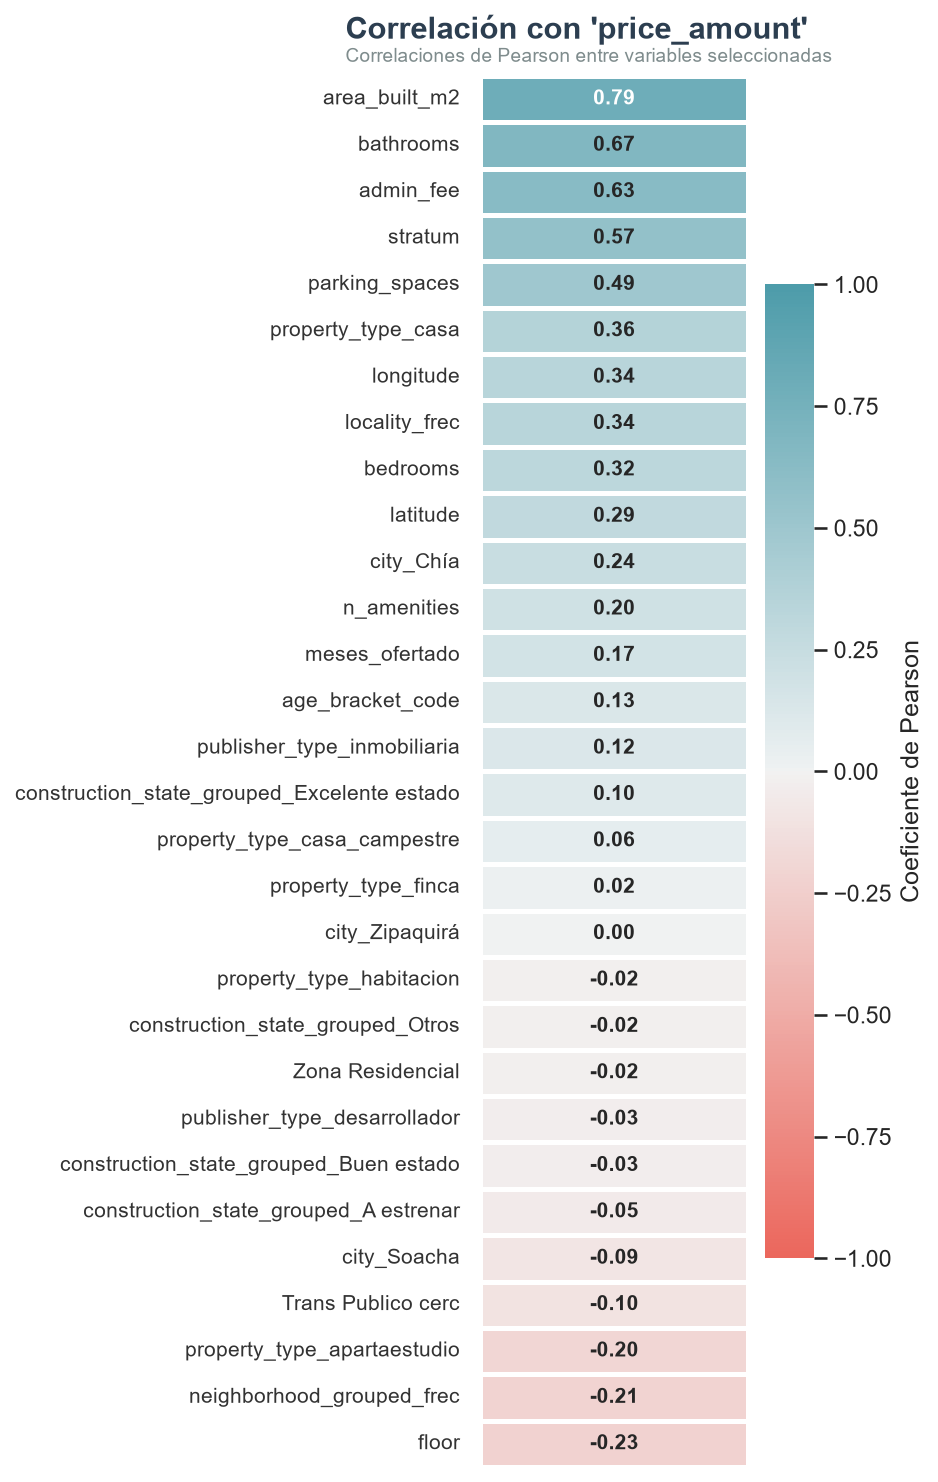

In [405]:
plot_target_correlation(df, df.columns.to_list(), "price_amount")

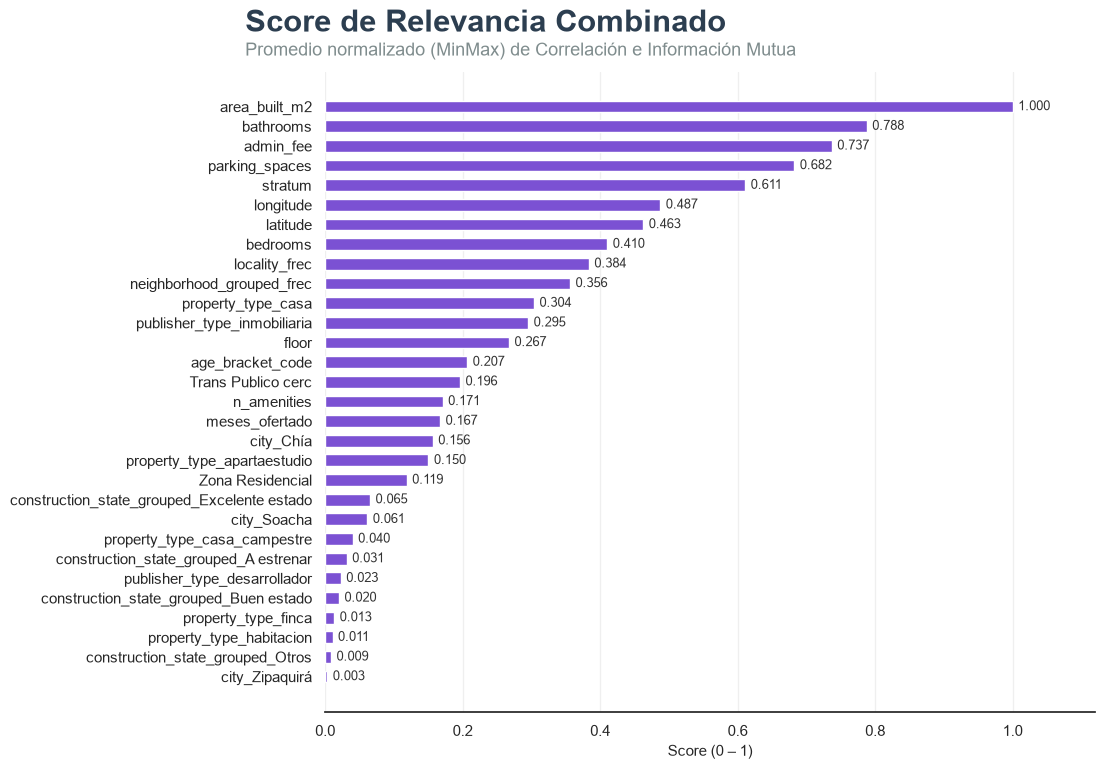

In [406]:
df_score = analizar_relevancia_caracteristicas(df, target="price_amount")

Las variables que parecen ser las mas importantes en relacion al precio son el area construida, los baños que tiene la propiedad, cuanto paga de administracion, los espacios de parqueo, el estrato, la longitud (es algo raro que sea mas importante que la latitud considerando que la separacion social fuerte en bogota se da de norte a sur y no al revez, en fases posteriores se evaluara la eliminacion de las coordenadas, probablemente la importancia mayor venga por los precios elevados de viviendas cerca de los cerros orientales como las de rosales) y la latitud.

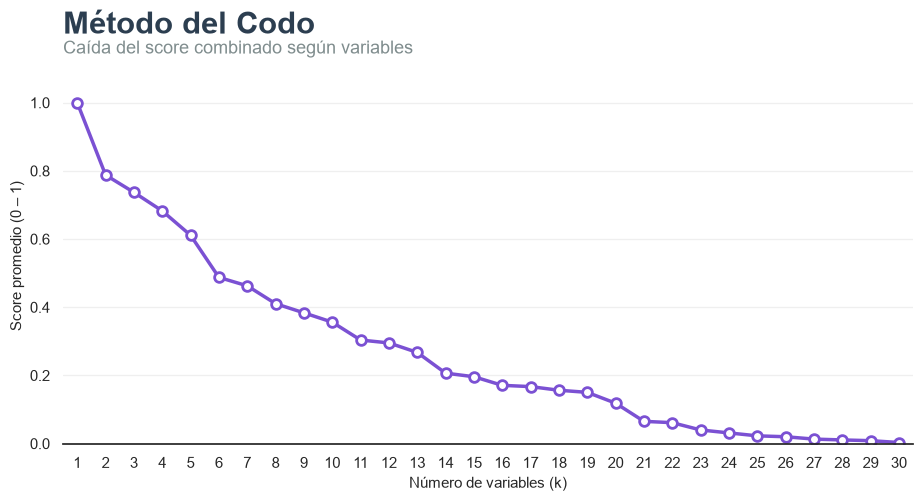

In [407]:
# --- 1. DATOS ORDENADOS ---
scores_ordenados = df_score["score"].sort_values(ascending=False).values

# --- 2. CREAR FIGURA ---
fig, ax = plt.subplots(figsize=(10, 5))

# TÍTULO ESTILO EDITORIAL
fig.text(
    0.1,
    0.95,
    "Método del Codo",
    fontsize=22,
    fontweight="bold",
    color="#2c3e50",
)
fig.text(
    0.1,
    0.91,
    "Caída del score combinado según variables",
    fontsize=13,
    color="#7f8c8d",
)

# --- 3. LÍNEA + PUNTOS ---
ax.plot(
    range(1, len(scores_ordenados) + 1),
    scores_ordenados,
    color="#7b51d3",
    linewidth=2.5,
    marker="o",
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="#7b51d3",
    markeredgewidth=2,
)

ax.set_xlabel("Número de variables (k)", fontsize=11)
ax.set_ylabel("Score promedio (0 – 1)", fontsize=11)
ax.set_xticks(range(1, len(scores_ordenados) + 1))
ax.set_xlim(0.5, len(scores_ordenados) + 0.5)
ax.set_ylim(0, scores_ordenados.max() * 1.1)
ax.grid(axis="y", alpha=0.3)

sns.despine(left=True, ax=ax)
plt.subplots_adjust(top=0.88, left=0.10, right=0.95, bottom=0.13)
plt.show()

No hay propiamente un codo claro, pero sugiere tomar aproximadamente 11 o 20 de las variables mas importantes

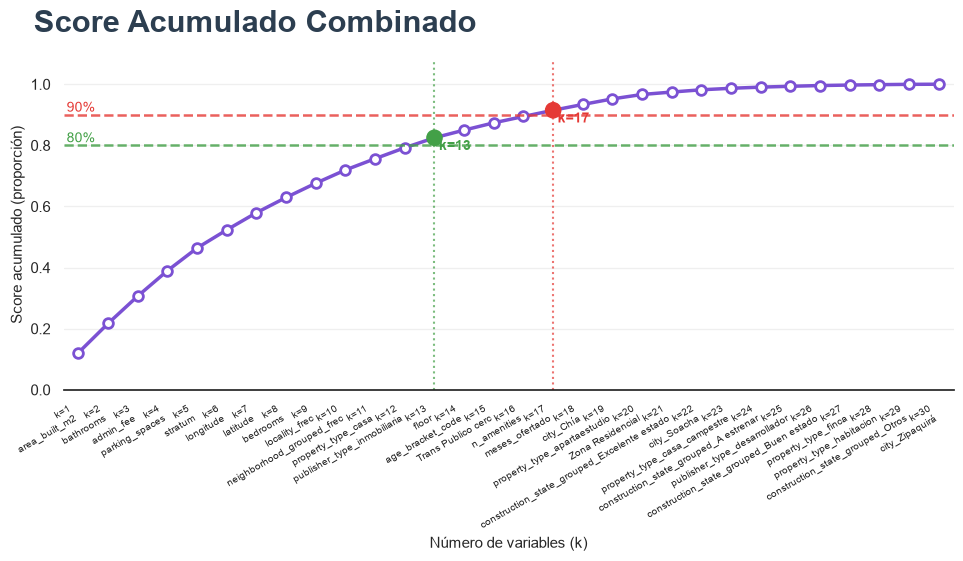

In [408]:
# --- 1. DATOS ACUMULADOS ---
scores_ord = df_score["score"].sort_values(ascending=False)
scores_norm = scores_ord / scores_ord.sum()
scores_acum = scores_norm.cumsum()

umbral_80 = (scores_acum >= 0.80).idxmax()
umbral_90 = (scores_acum >= 0.90).idxmax()
k_80 = scores_acum.index.get_loc(umbral_80) + 1
k_90 = scores_acum.index.get_loc(umbral_90) + 1

# --- 2. FIGURA ---
fig, ax = plt.subplots(figsize=(10, 5))

fig.text(
    0.05,
    0.98,
    "Score Acumulado Combinado",
    fontsize=22,
    fontweight="bold",
    color="#2c3e50",
    va="top",
)

# --- 3. LÍNEA ACUMULADA ---
ax.plot(
    range(1, len(scores_acum) + 1),
    scores_acum.values,
    color="#7b51d3",
    linewidth=2.5,
    marker="o",
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="#7b51d3",
    markeredgewidth=2,
)

# Umbrales
ax.axhline(0.80, color="#43A047", linestyle="--", linewidth=1.8, alpha=0.8)
ax.axhline(0.90, color="#E53935", linestyle="--", linewidth=1.8, alpha=0.8)

ax.text(len(scores_acum) * 0.02, 0.81, "80%", color="#43A047", fontsize=10)
ax.text(len(scores_acum) * 0.02, 0.91, "90%", color="#E53935", fontsize=10)

# Líneas verticales en k óptimo
ax.axvline(k_80, color="#43A047", linestyle=":", linewidth=1.5, alpha=0.7)
ax.axvline(k_90, color="#E53935", linestyle=":", linewidth=1.5, alpha=0.7)

ax.scatter(
    [k_80, k_90],
    [scores_acum.iloc[k_80 - 1], scores_acum.iloc[k_90 - 1]],
    color=["#43A047", "#E53935"],
    s=120,
    zorder=5,
)

ax.text(
    k_80 + 0.15,
    scores_acum.iloc[k_80 - 1] - 0.04,
    f"k={k_80}",
    color="#43A047",
    fontsize=10,
    fontweight="bold",
)
ax.text(
    k_90 + 0.15,
    scores_acum.iloc[k_90 - 1] - 0.04,
    f"k={k_90}",
    color="#E53935",
    fontsize=10,
    fontweight="bold",
)

ax.set_xlabel("Número de variables (k)", fontsize=11)
ax.set_ylabel("Score acumulado (proporción)", fontsize=11)
ax.set_xticks(range(1, len(scores_acum) + 1))
ax.set_xticklabels(
    [
        f"k={i}\n{scores_ord.index[i - 1]}"
        for i in range(1, len(scores_acum) + 1)
    ],
    fontsize=7.5,
    rotation=30,
    ha="right",
)
ax.set_ylim(0, 1.08)
ax.set_xlim(0.5, len(scores_acum) + 0.5)
ax.grid(axis="y", alpha=0.3)

sns.despine(left=True, ax=ax)
plt.subplots_adjust(top=0.88, left=0.08, right=0.97, bottom=0.22)
plt.show()

Sugiere utilizar entre 13 a 17 variables del top

Aunque se realizaron estos graficos la regresion se ajustara inicialmente con todas las variables, posteriormente siguiendo los resultados de estos graficos, para luego volver a usar todas las variables pero transformado las mas asimetricas con log, por ultimo se trabajara con esas log pero siguiendo lo que se hallo en estos graficos, esto con el fin de observar cual es el modelo con los coeficientes mas estables y que mejor cumple los supuestos del modelo, ademas de buscar si en alguno de los casos algun coeficiente que en principio no era significativo si que se vuelve.

Ademas el $R^2$ Adj. y $R^2$ se utlizara como metrica comparativa entre modelos, junto a las pruebas de los supuestos de regresion lineal por OLS.

Nota: ante los log(x) esos coeficientes no se toman como aumentos absolutos de uno si no como aumentos de un 1%.

* bajo $\log(Y) = \beta_0 + \beta_1 \log(X)$ la interpretacion correcta es: un incremento del $1\%$ en $X$ genera un cambio del $\beta_1\%$ en $Y$.
* bajo $Y = \beta_0 + \beta_1 \log(X)$ la interpretacion correcta es: Un incremento del $1\%$ en $X$ genera un cambio absoluto de $\frac{\beta_1}{100}$ unidades en $Y$ (pesos COP).

In [409]:
nombre_archivo = "../data/datos_inmobiliarios_ready.csv"


if os.path.exists(nombre_archivo):
    print(
        f"⚠️ El archivo '{nombre_archivo}' ya existe. No se sobrescribió nada."
    )
else:
    df.to_csv(nombre_archivo, index=False, encoding="utf-8")
    print(f"✅ Archivo '{nombre_archivo}' guardado correctamente.")

✅ Archivo '../data/datos_inmobiliarios_ready.csv' guardado correctamente.
